In [2]:
import numpy as np
import matplotlib.pyplot as plt
 
#1.1
def fair_coin():
    return np.random.rand()<0.5

In [ ]:
#1.2 and 1.4
def biased_coin(p):
    p_temp=p
    for _ in range(64):
        bit=1 if (fair_coin()) else 0
        p_bit=int(p_temp*2)%2
        p_temp=(p_temp*2)%1
        if bit>p_bit:
            return 0
        if bit<p_bit:
            return 1
    return 0
 
def biased_coin_count(p):
    p_temp=p
    tosses=0
    for i in range(64):
        bit=1 if (fair_coin()) else 0
        
        p_bit= int(p_temp * 2) % 2
        p_temp=(p_temp * 2) % 1
        
        if bit>p_bit:
            tosses=i+1
            return 0, tosses
        if bit<p_bit:
            tosses=i+1
            return 1, tosses
        
    return 0, 64
 

In [43]:
#1.5
n=100000
p_values=[0.3,0.7,0.125]
print(f"{'Theoretical P':>8} {'Empirical P'}")
for p in p_values:
    samples=np.array([biased_coin(p) for _ in range(n)])
    empirical= np.mean(samples)
    print(f"{p:>7} {empirical:>15}")

Theoretical P Empirical P
    0.3         0.30055
    0.7         0.70005
  0.125          0.1246


In [ ]:
#1.6
print(f"{'p':>8} {'Avg tosses':>12}")
for p in p_values:
    toss_counts=[]
    for _ in range(n):
        _,t=biased_coin_count(p)
        toss_counts.append(t)
    print(f"{p:>8.3f} {np.mean(toss_counts):>12.4f}")

       p   Avg tosses
   0.300       2.0027
   0.700       1.9970
   0.125       1.9999


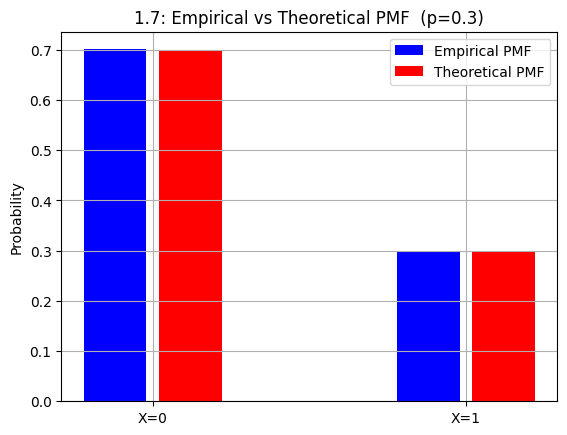

In [49]:
# Step 1.7
p_plot=0.3
samples7=np.array([biased_coin(p_plot) for i in range(n)])

emp_p0=np.mean(samples7==0)
emp_p1=np.mean(samples7==1)

plt.bar([0-0.12,1-0.12],[emp_p0,emp_p1], width=0.2,color='blue',label='Empirical PMF')
plt.bar([0+0.12,1+0.12],[1-p_plot,p_plot],width=0.2,color='red',label='Theoretical PMF')
plt.xticks([0,1],['X=0','X=1'])
plt.ylabel('Probability')
plt.title(f'1.7: Empirical vs Theoretical PMF  (p={p_plot})')
plt.legend()
plt.grid(True)
plt.show()